In [200]:
import os.path
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.fft import fft, fftfreq, ifft
from scipy.io.wavfile import read as read_wav
from scipy.signal import butter,filtfilt, savgol_filter, hilbert, find_peaks, find_peaks_cwt
from scipy.interpolate import interp1d


In [201]:
DATA_PATH = r'C:\Users\hsmach\Dropbox\Hanna.Smach\US_workshop_FUW_2023\2022-zdrowi-NIKARD'

T_RANGE = 70        # time scale range [s]
F_RANGE = 2000      # freq range [Hz]
AUDIO_FS, data = read_wav(os.path.join(DATA_PATH,"hania_pulse_leftCCA.wav")) # enter your filename
AUDIO_FS, data = read_wav(os.path.join(DATA_PATH,"hania_pulse_radial_artery.wav")) # enter your filename


In [202]:
doppler=data[:,0]

N = len(doppler)
T = 1/AUDIO_FS
dop_time=np.linspace(0, N*T, len(doppler))

In [203]:
# Fast Fourier Transform
fft_dop = fft(doppler)
freqs_dop = fftfreq(N,T)

cut_f_signal = fft_dop.copy()
# cut_f_signal[(freqs_dop<2)] = 0
cut_f_signal[(freqs_dop<15)] = 0    # HP filter
cut_signal = ifft(cut_f_signal)

In [204]:
speed_of_sound = 1540   # [m/s]
theta=0                 # angle correction [rad]
f0= 8e6                 # [Hz]

def convert_to_velo(f):
    return 100*speed_of_sound*f/(2*f0*math.cos(theta))  # [cm/s]

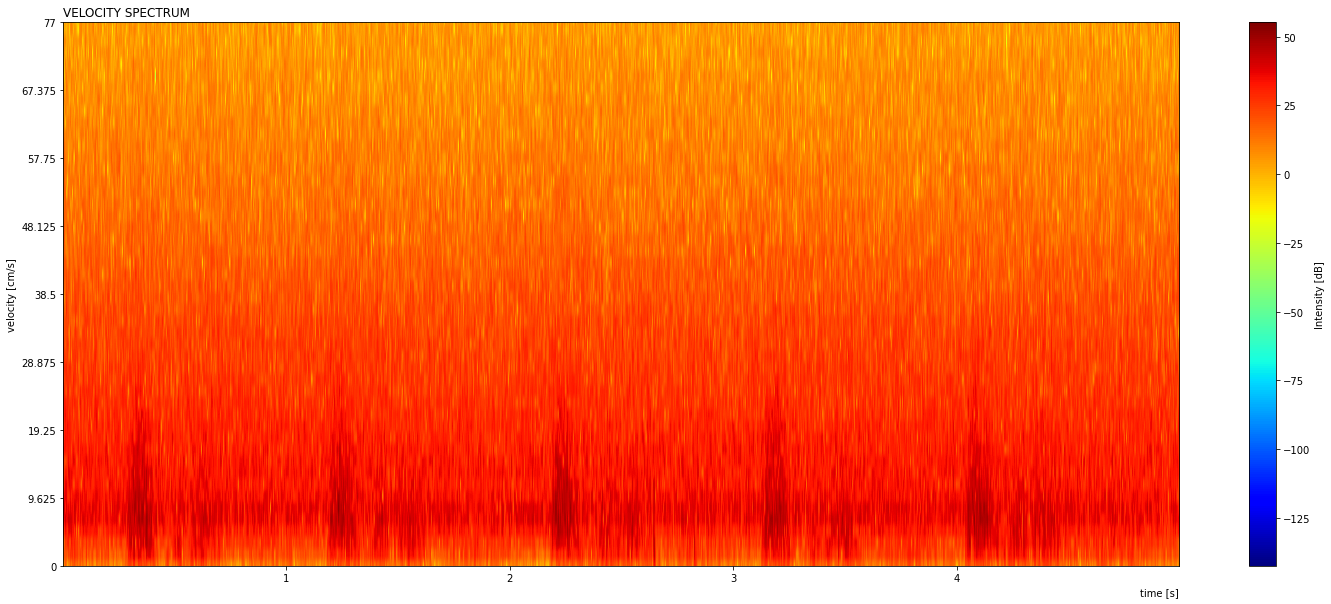

In [242]:
## Plot VELOCITY SPECTRUM
fig, axs = plt.subplots(figsize=(25, 10))
axs.set_title('VELOCITY SPECTRUM',loc='left')
axs.set_xlabel('time [s]',loc='right')
axs.set_ylabel('velocity [cm/s]')
# Pxx, freqs, bins, cax = axs.specgram(cut_signal, Fs=AUDIO_FS, noverlap=None, scale='dB', cmap='jet', mode='psd')
Pxx, freqs, bins, cax = axs.specgram(cut_signal[10*AUDIO_FS:15*AUDIO_FS], Fs=AUDIO_FS, noverlap=None, scale='dB', cmap='jet', mode='psd')
axs.set_ylim(0,4*F_RANGE)
# axs.set_xlim(10,15)

ticks_y = ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(convert_to_velo(x)))
axs.yaxis.set_major_formatter(ticks_y)

fig.colorbar(cax).set_label('Intensity [dB]')

In [206]:
## set of functions for envelope detection

def hl_envelopes_idx(s, dmin=1, dmax=1, split=False):
    """
    Input :
    s: 1d-array, data signal from which to extract high and low envelopes
    dmin, dmax: int, optional, size of chunks, use this if the size of the input signal is too big
    split: bool, optional, if True, split the signal in half along its mean, might help to generate the envelope in some cases
    Output :
    lmin,lmax : high/low envelope idx of input signal s
    """

    # locals min      
    lmin = (np.diff(np.sign(np.diff(s))) > 0).nonzero()[0] + 1 
    # locals max
    lmax = (np.diff(np.sign(np.diff(s))) < 0).nonzero()[0] + 1 
    
    if split:
        # s_mid is zero if s centered around x-axis or more generally mean of signal
        s_mid = np.mean(s) 
        # pre-sorting of locals min based on relative position with respect to s_mid 
        lmin = lmin[s[lmin]<s_mid]
        # pre-sorting of local max based on relative position with respect to s_mid 
        lmax = lmax[s[lmax]>s_mid]

    # global min of dmin-chunks of locals min 
    lmin = lmin[[i+np.argmin(s[lmin[i:i+dmin]]) for i in range(0,len(lmin),dmin)]]
    # global max of dmax-chunks of locals max 
    lmax = lmax[[i+np.argmax(s[lmax[i:i+dmax]]) for i in range(0,len(lmax),dmax)]]
    return lmin,lmax


def get_envelope(x, y):
    x_list, y_list = list(x), list(y)
    assert len(x_list) == len(y_list)
    
    # First data
    ui, ux, uy = [0], [x_list[0]], [y_list[0]]
    li, lx, ly = [0], [x_list[0]], [y_list[0]]

    # Find upper peaks and lower peaks
    for i in range(1, len(x_list)-1):
        if y_list[i] >= y_list[i-1] and y_list[i] >= y_list[i+1]:
            ui.append(i)
            ux.append(x_list[i])
            uy.append(y_list[i])
        if y_list[i] <= y_list[i-1] and y_list[i] <= y_list[i+1]:
            li.append(i)
            lx.append(x_list[i])
            ly.append(y_list[i])

    # Last data
    ui.append(len(x_list)-1)
    ux.append(x_list[-1])
    uy.append(y_list[-1])
    li.append(len(y_list)-1)
    lx.append(x_list[-1])
    ly.append(y_list[-1])  

    if len(ux) == 2 or len(lx) == 2:
        return [], []
    
    else:
        func_ub = interp1d(ux, uy, kind='cubic', bounds_error=False)
        func_lb = interp1d(lx, ly, kind='cubic', bounds_error=False)

        ub, lb = [], []
        for i in x_list:
            ub = func_ub(x_list)
            lb = func_lb(x_list)

        ub = np.array([y, ub]).max(axis=0)
        lb = np.array([y, lb]).min(axis=0)

        return ub, lb

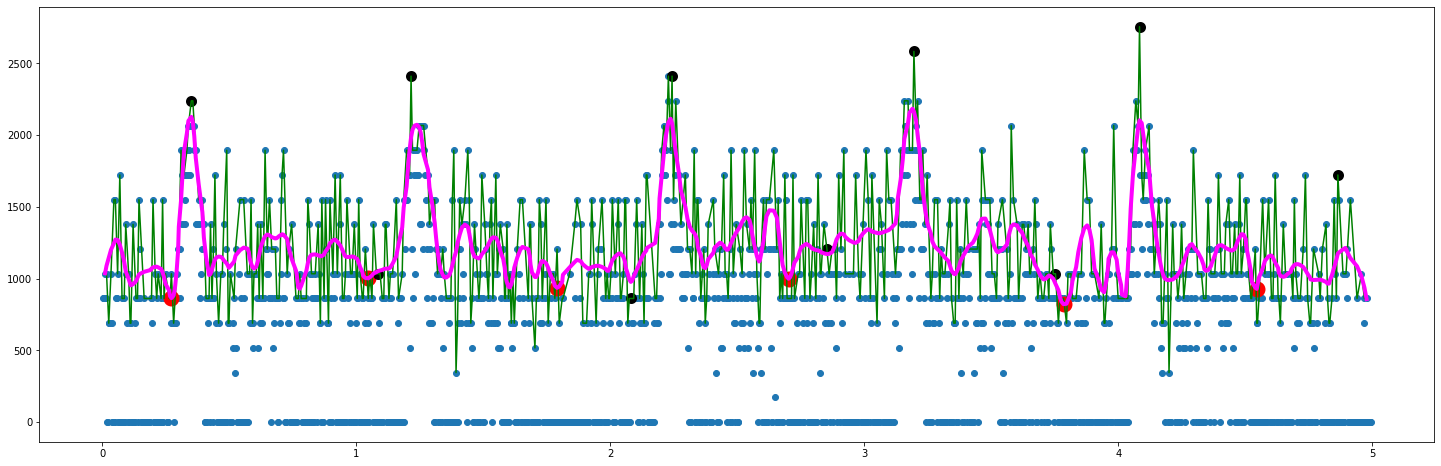

In [238]:
A,B = Pxx.shape
ardB= 10*np.log10((Pxx[round(A/2):,:]))
threshold = 39 # in dB

# fD=freqs
# v=convert_to_velo(fD)     # [cm/s]

vec_th=np.zeros(B)
for i in range(B):
    try:
        maxiIx= np.where(ardB[:,i]>threshold)[0][-1]
    except:
        maxiIx=0
    vi=maxiIx + round(A/2)
    vec_th[i]=freqs[vi]

## Plot velocity spectrum ENVELOPE (maximum values) -> pseudo-envelope
fig, axs = plt.subplots(figsize=(25,8))
axs.scatter(bins,vec_th)

__, lmax = hl_envelopes_idx(vec_th.copy())
axs.plot(bins[lmax], vec_th[lmax], 'green', label='high')
env_time1=bins[lmax]
env_val1=vec_th[lmax]

uy, ly = get_envelope(bins.copy(), vec_th.copy()) # identical


vel_fs = 1/np.diff(env_time1)[0] # new sampling rate
b, a = butter(3, 2*15/vel_fs, btype='low', analog=False)
output = filtfilt(b, a, env_val1.copy())
axs.plot(env_time1,output, 'magenta', linewidth=4)

# output_smoothed=savgol_filter(env_val, 25, 3)
# axs.plot(env_time,output_smoothed, 'magenta')

# fiterp = interpolate.interp1d(bins[lmax], vec_th[lmax])
# env_inter= fiterp(bins)
# axs.plot(bins,env_inter)

# sig_trans = hilbert(vec_th)
# sig_envelope = np.abs(sig_trans)
# output_smoothed=savgol_filter(sig_envelope, round(vel_fs/10), 3)
# axs.plot(bins,output_smoothed, 'magenta')

# # smooth with LP filter - 15 HZ source: https://sci-hub.se/10.1109/CIC.1996.542505

# vel_fs = 1/np.diff(bins)[0] # new sampling rate for velocity
# print(vel_fs)
# b, a = butter(3, 2*15/vel_fs, btype='low', analog=False)
# output = filtfilt(b, a, vec_th.copy())
# output_smoothed=savgol_filter(output, round(vel_fs/10), 3)
# axs.plot(bins,output_smoothed, 'magenta')

peaks, __ = find_peaks(env_val1,distance=0.5*1/np.diff(env_time1)[0])
axs.scatter(env_time1[peaks],env_val1[peaks],color='black', linewidth=5)

minimas, __ = find_peaks(-output,distance=0.5*1/np.diff(env_time1)[0])
axs.scatter(env_time1[minimas],output[minimas],color='red', linewidth=10)

# source https://www.samproell.io/posts/signal/peak-finding-python-js/
dist=round(0.5*1/np.diff(env_time1)[0])
cwt_peaks = find_peaks_cwt(-env_val1, widths=np.arange(10, dist))
axs.scatter(env_time1[cwt_peaks],env_val1[cwt_peaks],color='black', linewidth=5)

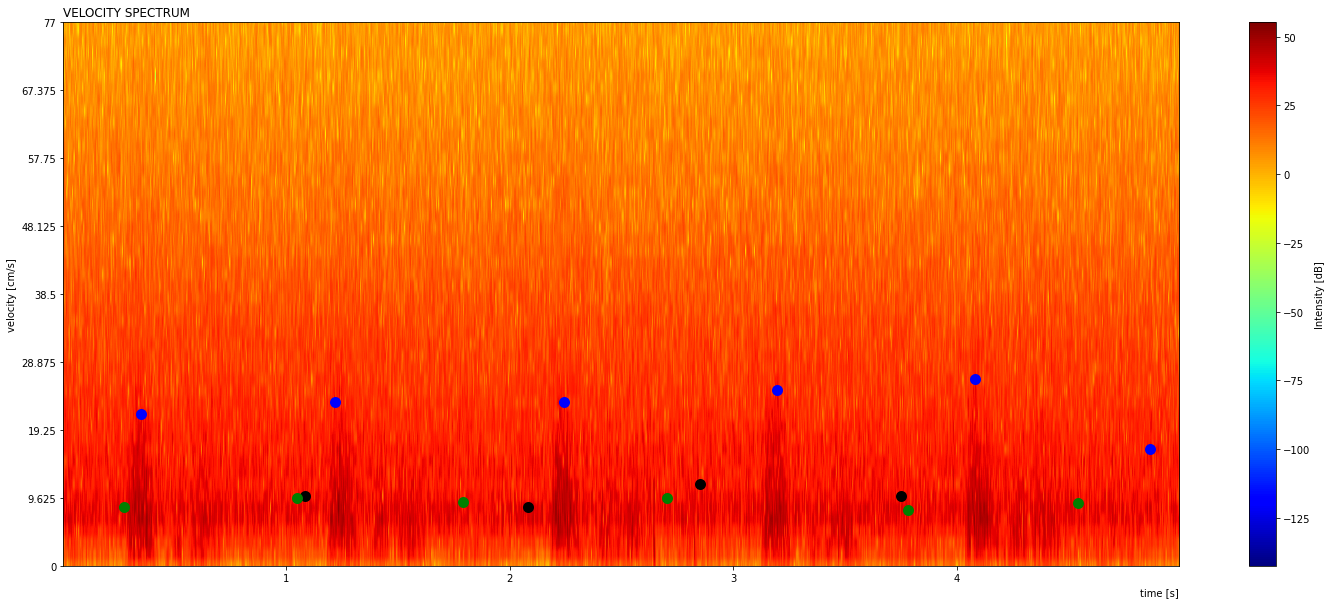

In [239]:
## Plot VELOCITY SPECTRUM
fig, axs = plt.subplots(figsize=(25, 10))
axs.set_title('VELOCITY SPECTRUM',loc='left')
axs.set_xlabel('time [s]',loc='right')
axs.set_ylabel('velocity [cm/s]')
__, __, __, cax = axs.specgram(cut_signal[10*AUDIO_FS:15*AUDIO_FS], Fs=AUDIO_FS, noverlap=None, scale='dB', cmap='jet', mode='psd')
axs.set_ylim(0,4*F_RANGE)

axs.scatter(env_time1[peaks],env_val1[peaks],color='blue', linewidth=5)
axs.scatter(env_time1[cwt_peaks],env_val1[cwt_peaks],color='black', linewidth=5)
axs.scatter(env_time1[minimas],output[minimas],color='green', linewidth=5)

# axs.plot(env_time1,output,'green')

ticks_y = ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(convert_to_velo(x)))
axs.yaxis.set_major_formatter(ticks_y)

fig.colorbar(cax).set_label('Intensity [dB]')

In [211]:
data = env_val1.copy()
data[data == 0] = np.nan
MV = np.nanmean(convert_to_velo(data))
print('MV ', MV)

PSV = np.mean(convert_to_velo(env_val1[peaks]))
print('PSV ', PSV)
EDV = np.mean(convert_to_velo(env_val1[cwt_peaks]))
# EDV = np.mean(convert_to_velo(env_val1[minimas]))
print('EDV ', EDV)

# # Resistance Index and Pulsatility Index
RI = (PSV-EDV)/PSV
print('\nRI ', RI)
# normal range of RI is 0.5-0.7 (in both CCA and RA)

PI = (PSV-EDV)/MV
print('\nPI ', PI)
# normal range of PI is <1.5 for CCA
# normal range for MCA 0.5 – 1.2
# https://i0.wp.com/emcrit.org/wp-content/uploads/2022/02/doppler-norms.jpg?resize=500%2C351&ssl=1
# https://sci-hub.se/10.7863/ultra.16.04050

MV  11.745728975183823
PSV  23.876015625
EDV  9.94833984375

RI  0.5833333333333334

PI  1.1857651245551601


In [199]:
MV = (PSV + 2*EDV)/3
MV 
# https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8774649/

14.535629882812499

In [ ]:
# the usual normal velocity of the common carotid artery is 30-40 cm/sec 
# https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4058969/

# The blood velocity of the right and left radial arteries was measured as 7.2(4.2 − 10.2) cm/s and 8.8(6.6 − 11.3) cm/s
# Krullaards, R. L., Pel, J. J., Snijders, C. J., & Kleinrensink, G. J. (2009). The potential effects of a biofeedback writing exercise on radial artery blood flow and neck mobility. International Journal of Biomedical Science: IJBS, 5(2), 192.
# typical mean values: 8-16

In [ ]:
# https://docs.scipy.org/doc/scipy-0.16.0/reference/generated/scipy.signal.spectrogram.html